# Siamese Neural Networks for One-shot Image Recognition
### Reprodução do artigo de Koch, Zemel & Salakhutdinov (2015) — adaptado para o Google Colab

Este notebook reproduz, de forma simplificada, o experimento do artigo *"Siamese Neural Networks for One-shot Image Recognition"* no dataset **Omniglot**:

1. Treina uma rede siamesa convolucional na tarefa de **verificação** (prever se um par de imagens pertence à mesma classe de caractere ou a classes diferentes).
2. Reutiliza as features aprendidas para resolver tarefas de **classificação one-shot N-way** em alfabetos nunca vistos durante o treino (evaluation set do Omniglot).

**Antes de rodar:** em `Ambiente de execução > Alterar tipo de ambiente de execução`, selecione uma **GPU** (T4 é suficiente).

> Nota de adaptação: para manter o tempo de execução razoável no Colab (gratuito), usamos por padrão um número menor de épocas e pares de treino do que o artigo original (que usava até 150k/1.35M pares e 200 épocas). Os hiperparâmetros e a arquitetura seguem fielmente a Figura 4 e a Seção 3 do artigo; aumente `NUM_TRAIN_PAIRS` e `EPOCHS` na Seção 5 se quiser se aproximar mais dos números reportados (92% de acurácia one-shot 20-way).

## 1. Setup e imports

In [1]:
import os
import glob
import random
import itertools
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.datasets import Omniglot
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo em uso:', device)
if device.type != 'cuda':
    print('AVISO: nenhuma GPU detectada. Vá em Ambiente de execução > Alterar tipo '
          'de ambiente de execução > GPU para acelerar o treino.')

Dispositivo em uso: cuda


## 2. Download do dataset Omniglot

O `torchvision` já inclui o Omniglot e cuida do download/extração automaticamente.
- `background=True`  → **background set** (40 alfabetos) usado para treino/validação (aprender features).
- `background=False` → **evaluation set** (10 alfabetos) usado **apenas** para medir a acurácia one-shot final, exatamente como no artigo (Seção 4.1).

In [2]:
DATA_DIR = './data'

background_ds = Omniglot(root=DATA_DIR, background=True, download=True)
evaluation_ds = Omniglot(root=DATA_DIR, background=False, download=True)

print('Pasta background :', background_ds.target_folder)
print('Pasta evaluation  :', evaluation_ds.target_folder)

100%|██████████| 9.46M/9.46M [00:00<00:00, 191MB/s]
100%|██████████| 6.46M/6.46M [00:00<00:00, 117MB/s]


Pasta background : ./data/omniglot-py/images_background
Pasta evaluation  : ./data/omniglot-py/images_evaluation


## 3. Organização dos dados por alfabeto / caractere / desenhista ("drawer")

Cada caractere do Omniglot possui 20 imagens (uma por desenhista). Construímos um
dicionário `{alfabeto: {caractere: [caminhos_das_20_imagens]}}`, que espelha a
estrutura usada no artigo (Seção 4.1) para gerar pares de verificação e trials de
one-shot learning.

In [3]:
def build_alphabet_dict(root_dir):
    """Constroi {alfabeto: {caractere: [caminhos das imagens]}}."""
    alphabets = {}
    for alphabet_name in sorted(os.listdir(root_dir)):
        alphabet_path = os.path.join(root_dir, alphabet_name)
        if not os.path.isdir(alphabet_path):
            continue
        chars = {}
        for char_name in sorted(os.listdir(alphabet_path)):
            char_path = os.path.join(alphabet_path, char_name)
            imgs = sorted(glob.glob(os.path.join(char_path, '*.png')))
            if len(imgs) >= 2:
                chars[char_name] = imgs
        alphabets[alphabet_name] = chars
    return alphabets


background_alphabets = build_alphabet_dict(background_ds.target_folder)
evaluation_alphabets = build_alphabet_dict(evaluation_ds.target_folder)

# Separamos uma fração dos ALFABETOS do background set para validação,
# análogo à divisão treino/validação/teste da Seção 4.2 do artigo.
bg_names = list(background_alphabets.keys())
random.shuffle(bg_names)
n_val_alphabets = max(1, int(0.15 * len(bg_names)))
val_alphabet_names = set(bg_names[:n_val_alphabets])
train_alphabet_names = set(bg_names[n_val_alphabets:])

train_alphabets = {k: v for k, v in background_alphabets.items() if k in train_alphabet_names}
val_alphabets = {k: v for k, v in background_alphabets.items() if k in val_alphabet_names}

print(f'Alfabetos - treino: {len(train_alphabets)} | validação: {len(val_alphabets)} | '
      f'avaliação (one-shot final): {len(evaluation_alphabets)}')

Alfabetos - treino: 26 | validação: 4 | avaliação (one-shot final): 20


## 4. Dataset de pares (tarefa de verificação) com distorções afins

Reproduz a Figura 2 e a Seção 3.2 ("Affine distortions") do artigo: a cada imagem,
com probabilidade 0.5, aplicamos uma transformação afim aleatória
(rotação ±10°, translação ±2px, escala 0.8–1.2, cisalhamento) para aumentar os dados.

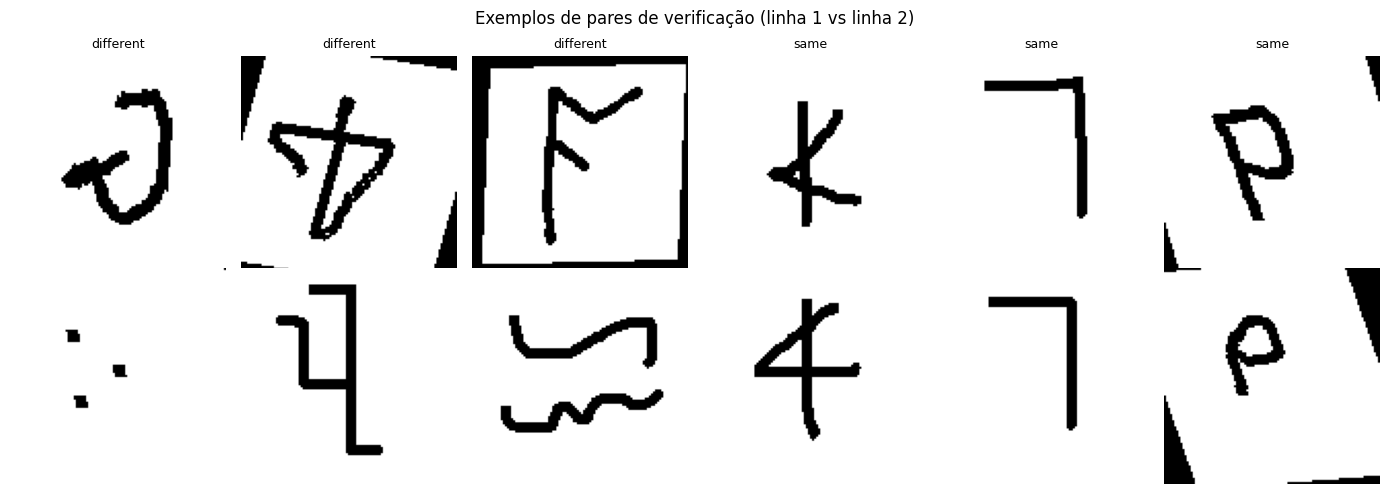

In [4]:
IMAGE_SIZE = 105  # mesmo tamanho de entrada do artigo (Figura 4)

class OmniglotPairs(Dataset):
    """Gera pares (img1, img2, label) — label=1 mesma classe, label=0 classes diferentes."""

    def __init__(self, alphabets_dict, num_pairs=30000, augment=True, image_size=IMAGE_SIZE):
        self.num_pairs = num_pairs
        self.augment = augment
        self.image_size = image_size

        # lista de listas de caminhos de imagem, uma lista por caractere
        self.char_pools = []
        for chars in alphabets_dict.values():
            for imgs in chars.values():
                self.char_pools.append(imgs)

        self.resize = T.Resize((image_size, image_size))
        self.to_tensor = T.ToTensor()
        self.affine = T.RandomAffine(degrees=10, translate=(2/image_size, 2/image_size),
                                      scale=(0.8, 1.2), shear=15)

    def __len__(self):
        return self.num_pairs

    def _load(self, path):
        img = Image.open(path).convert('L')
        img = self.resize(img)
        if self.augment and random.random() < 0.5:
            img = self.affine(img)
        return self.to_tensor(img)

    def __getitem__(self, idx):
        if random.random() < 0.5:
            pool = random.choice(self.char_pools)
            p1, p2 = random.sample(pool, 2)
            label = 1.0
        else:
            pool1, pool2 = random.sample(self.char_pools, 2)
            p1 = random.choice(pool1)
            p2 = random.choice(pool2)
            label = 0.0
        img1 = self._load(p1)
        img2 = self._load(p2)
        return img1, img2, torch.tensor(label, dtype=torch.float32)


# Visualiza alguns pares de exemplo
_tmp_ds = OmniglotPairs(train_alphabets, num_pairs=6, augment=True)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    img1, img2, label = _tmp_ds[i]
    axes[0, i].imshow(img1.squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(img2.squeeze(), cmap='gray'); axes[1, i].axis('off')
    axes[0, i].set_title('same' if label == 1 else 'different', fontsize=9)
plt.suptitle('Exemplos de pares de verificação (linha 1 vs linha 2)')
plt.tight_layout()
plt.show()

## 5. Arquitetura da rede siamesa (Figura 3 e Figura 4 do artigo)

- 4 camadas convolucionais (64, 128, 128, 256 filtros) com ReLU e max-pooling 2x2 nas 3 primeiras.
- Camada fully-connected de 4096 unidades com ativação sigmoide (o "feature vector" da Figura 4).
- Distância L1 ponderada entre os dois vetores de features dos "gêmeos" (twins), seguida de uma
  camada fully-connected final de saída, com **pesos compartilhados** entre as duas torres.
- Inicialização de pesos seguindo a Seção 3.2 ("Weight initialization") do artigo.

In [5]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=10), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=7), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, kernel_size=4), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=4), nn.ReLU(inplace=True),
        )
        # com entrada 105x105: 96->48->42->21->18->9->6  =>  256 * 6 * 6
        self.fc_embedding = nn.Sequential(
            nn.Linear(256 * 6 * 6, 4096),
            nn.Sigmoid(),
        )
        self.out = nn.Linear(4096, 1)  # combina a distância L1 componente a componente (alpha_j)

    def forward_once(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc_embedding(x)
        return x

    def forward(self, x1, x2):
        h1 = self.forward_once(x1)   # rede "gêmea" 1 (pesos compartilhados)
        h2 = self.forward_once(x2)   # rede "gêmea" 2 (mesmos pesos, self.forward_once é reutilizado)
        dist = torch.abs(h1 - h2)    # distância L1 componente a componente
        logits = self.out(dist).squeeze(1)
        return logits                # logits; usar BCEWithLogitsLoss (sigmoide aplicada na loss)


def init_weights(m):
    """Inicialização descrita na Seção 3.2 ('Weight initialization') do artigo."""
    if isinstance(m, nn.Conv2d):
        nn.init.normal_(m.weight, mean=0.0, std=1e-2)
        nn.init.normal_(m.bias, mean=0.5, std=1e-2)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=2e-1)
        nn.init.normal_(m.bias, mean=0.5, std=1e-2)


model = SiameseNetwork().to(device)
model.apply(init_weights)
n_params = sum(p.numel() for p in model.parameters())
print(f'Rede siamesa criada com {n_params:,} parâmetros.')

Rede siamesa criada com 38,951,745 parâmetros.


## 6. Avaliação one-shot N-way (Seção 4.3 do artigo)

Reproduz o protocolo de avaliação da Figura 1: escolhe um alfabeto do **evaluation set**,
sorteia N caracteres, usa um desenhista para formar o "support set" (1 imagem por classe)
e outro desenhista para a imagem de consulta (query). A classe prevista é a de maior
similaridade `p` segundo a rede.

In [6]:
def load_image(path, image_size=IMAGE_SIZE):
    img = Image.open(path).convert('L').resize((image_size, image_size))
    return T.ToTensor()(img)


def one_shot_trial(model, alphabets_dict, n_way=20, image_size=IMAGE_SIZE):
    candidates = [a for a, chars in alphabets_dict.items() if len(chars) >= n_way]
    alphabet = random.choice(candidates)
    chars = alphabets_dict[alphabet]
    char_names = random.sample(list(chars.keys()), n_way)

    correct_idx = random.randint(0, n_way - 1)
    support_paths, query_path = [], None
    for i, cname in enumerate(char_names):
        d_query, d_support = random.sample(chars[cname], 2)
        support_paths.append(d_support)
        if i == correct_idx:
            query_path = d_query

    query = load_image(query_path, image_size).unsqueeze(0).repeat(n_way, 1, 1, 1).to(device)
    support = torch.stack([load_image(p, image_size) for p in support_paths]).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(query, support))
    pred_idx = torch.argmax(probs).item()
    return pred_idx == correct_idx, query_path, support_paths, probs.cpu().numpy(), correct_idx


def one_shot_accuracy(model, alphabets_dict, n_way=20, trials=100):
    correct = 0
    for _ in range(trials):
        ok, *_ = one_shot_trial(model, alphabets_dict, n_way=n_way)
        correct += int(ok)
    return correct / trials

## 7. Treinamento

Ajuste `NUM_TRAIN_PAIRS`, `BATCH_SIZE` e `EPOCHS` conforme o tempo/GPU disponíveis.
Os valores padrão abaixo são reduzidos em relação ao artigo (que usava até 150k pares e
200 épocas) para caber confortavelmente em uma sessão gratuita do Colab; a arquitetura,
a função de perda e o protocolo de avaliação permanecem fiéis ao paper.

In [7]:
NUM_TRAIN_PAIRS = 20000     # artigo usa 30k / 90k / 150k (ver Tabela 1)
BATCH_SIZE = 64             # artigo usa minibatch de 128
EPOCHS = 15                 # artigo treina até 200 épocas, com early stopping
LEARNING_RATE = 1e-4
EVAL_EVERY_N_WAY = 20       # tarefa one-shot 20-way, como na Tabela 2
EVAL_TRIALS_PER_EPOCH = 100 # reduzido de 400 (artigo) para acelerar o monitoramento

train_dataset = OmniglotPairs(train_alphabets, num_pairs=NUM_TRAIN_PAIRS, augment=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, drop_last=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

history = {'loss': [], 'val_one_shot_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        logits = model(img1, img2)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * img1.size(0)

    avg_loss = total_loss / len(train_dataset)
    val_acc = one_shot_accuracy(model, val_alphabets, n_way=EVAL_EVERY_N_WAY,
                                 trials=EVAL_TRIALS_PER_EPOCH)
    history['loss'].append(avg_loss)
    history['val_one_shot_acc'].append(val_acc)
    print(f'Época {epoch:2d}/{EPOCHS} | loss treino: {avg_loss:.4f} | '
          f'acurácia one-shot {EVAL_EVERY_N_WAY}-way (validação): {val_acc*100:.1f}%')

Época  1/15 | loss treino: 0.6059 | acurácia one-shot 20-way (validação): 17.0%
Época  2/15 | loss treino: 0.5596 | acurácia one-shot 20-way (validação): 16.0%
Época  3/15 | loss treino: 0.5319 | acurácia one-shot 20-way (validação): 27.0%
Época  4/15 | loss treino: 0.5211 | acurácia one-shot 20-way (validação): 20.0%
Época  5/15 | loss treino: 0.4870 | acurácia one-shot 20-way (validação): 21.0%
Época  6/15 | loss treino: 0.4646 | acurácia one-shot 20-way (validação): 25.0%
Época  7/15 | loss treino: 0.4316 | acurácia one-shot 20-way (validação): 22.0%
Época  8/15 | loss treino: 0.4069 | acurácia one-shot 20-way (validação): 33.0%
Época  9/15 | loss treino: 0.3742 | acurácia one-shot 20-way (validação): 39.0%
Época 10/15 | loss treino: 0.3575 | acurácia one-shot 20-way (validação): 39.0%
Época 11/15 | loss treino: 0.3378 | acurácia one-shot 20-way (validação): 41.0%
Época 12/15 | loss treino: 0.3125 | acurácia one-shot 20-way (validação): 41.0%
Época 13/15 | loss treino: 0.3018 | acur

## 8. Curvas de treino

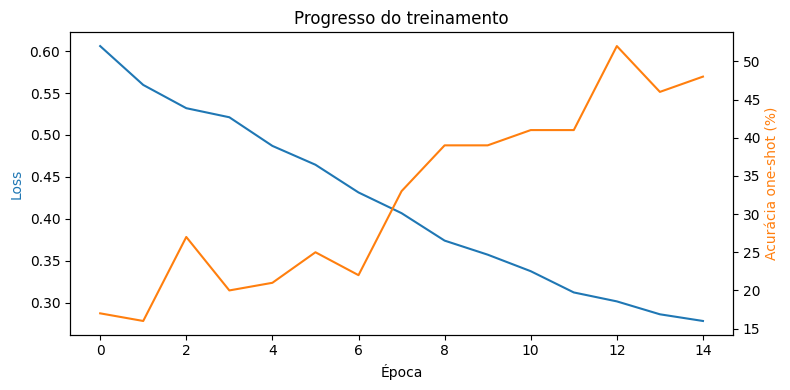

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history['loss'], color='tab:blue', label='Loss (treino)')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot([a * 100 for a in history['val_one_shot_acc']], color='tab:orange',
         label=f'Acurácia one-shot {EVAL_EVERY_N_WAY}-way (%)')
ax2.set_ylabel('Acurácia one-shot (%)', color='tab:orange')
plt.title('Progresso do treinamento')
fig.tight_layout()
plt.show()

## 9. Avaliação final no *evaluation set* (Tabela 2 do artigo)

Aqui medimos a acurácia one-shot 20-way no conjunto de **avaliação** (10 alfabetos nunca
vistos durante o treino nem a validação), da mesma forma que a Tabela 2 do artigo original.

In [9]:
FINAL_TRIALS = 400  # mesmo número de trials do artigo (Seção 4.3)

final_acc = one_shot_accuracy(model, evaluation_alphabets, n_way=20, trials=FINAL_TRIALS)
print(f'Acurácia one-shot 20-way no evaluation set ({FINAL_TRIALS} trials): {final_acc*100:.2f}%')
print('\nReferências do artigo (Tabela 2) para comparação:')
print(' Humanos.......................... 95.5%')
print(' Hierarchical Bayesian Program Learning (HBPL) 95.2%')
print(' Convolutional Siamese Net (artigo original)... 92.0%')
print(' 1-Nearest Neighbor............... 21.7%')

Acurácia one-shot 20-way no evaluation set (400 trials): 31.75%

Referências do artigo (Tabela 2) para comparação:
 Humanos.......................... 95.5%
 Hierarchical Bayesian Program Learning (HBPL) 95.2%
 Convolutional Siamese Net (artigo original)... 92.0%
 1-Nearest Neighbor............... 21.7%


## 10. Visualização de um trial one-shot (reproduz a Figura 1 do artigo)

Mostra a imagem de consulta (query) e o "grid" de imagens candidatas (support set),
destacando em verde a previsão do modelo e em vermelho a classe correta, caso o
modelo tenha errado.

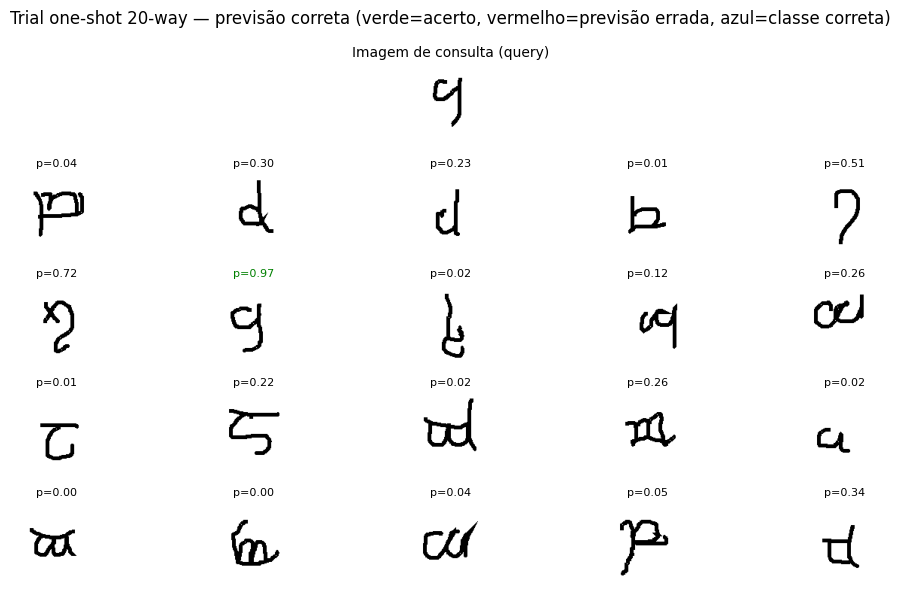

In [10]:
ok, query_path, support_paths, probs, correct_idx = one_shot_trial(
    model, evaluation_alphabets, n_way=20)
pred_idx = int(np.argmax(probs))

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(5, 5)

ax_query = fig.add_subplot(gs[0, 2])
ax_query.imshow(Image.open(query_path).convert('L'), cmap='gray')
ax_query.set_title('Imagem de consulta (query)', fontsize=10)
ax_query.axis('off')

for i, path in enumerate(support_paths):
    r, c = divmod(i, 5)
    ax = fig.add_subplot(gs[r + 1, c])
    ax.imshow(Image.open(path).convert('L'), cmap='gray')
    ax.axis('off')
    color = 'black'
    if i == pred_idx:
        color = 'green' if pred_idx == correct_idx else 'red'
    elif i == correct_idx:
        color = 'blue'
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(color); spine.set_linewidth(3)
    ax.set_title(f'p={probs[i]:.2f}', fontsize=8, color=color)

plt.suptitle(f'Trial one-shot 20-way — previsão {"correta" if ok else "incorreta"} '
             '(verde=acerto, vermelho=previsão errada, azul=classe correta)')
plt.tight_layout()
plt.show()

## 11. Próximos passos / adaptações possíveis

- Aumentar `NUM_TRAIN_PAIRS` para 90.000–150.000 e `EPOCHS` para se aproximar dos 92% do artigo.
- Implementar otimização de hiperparâmetros por camada (learning rate, momentum, L2) como na Seção 3.2, via Optuna ou Ray Tune (o artigo original usou o Whetlab, hoje descontinuado).
- Testar o modelo treinado no MNIST (Seção 4.4 do artigo), tratando os 10 dígitos como um "alfabeto" de 10 classes.
- Salvar os pesos do modelo (`torch.save(model.state_dict(), 'siamese_omniglot.pt')`) para reutilizar sem retreinar.